In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
from pprint import pprint
from html_table_parser.parser import HTMLTableParser
import pandas as pd
from matplotlib import rcParams
from yahooquery import Ticker
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
from pandas_datareader import data as pdr
pd.options.display.float_format = '{:,}'.format
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from datetime import datetime
from numpy import mean
from numpy import std
from numpy import absolute
from pandas import read_csv
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import Lasso
import yfinance as yf
from sklearn.model_selection import train_test_split
import math
from sklearn.linear_model import LogisticRegression
from sklearn import linear_model
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,r2_score,mean_squared_error
from fredapi import Fred
from pandas_datareader import data as pdr

pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Collection

## Inflation

In [36]:
fred = Fred(api_key='65a518324eaf9391db6bc3a2713997ac')
inflation = pdr.get_data_fred('CPIAUCSL').pct_change(periods=12) * 100

In [37]:
inflation.sort_values(by='DATE', ascending=False).head()

,CPIAUCSL
DATE,
2026-05-01,4.167
2026-04-01,3.779
2026-03-01,3.286
2026-02-01,2.434
2026-01-01,2.391


In [ ]:
employed = pd.DataFrame(fred.get_series('PAYEMS')).reset_index() #mortgage rates
employed['employed_difference'] = employed[0] - employed[0].shift(1)
employed['employed_difference'] = employed['employed_difference']*1000
employed.columns = ['date','employed','employed_difference']

In [44]:
employment_nonfarm = pdr.get_data_fred('PAYEMS')

In [45]:
employment_nonfarm.head()

,PAYEMS
DATE,
2021-07-01,146762
2021-08-01,147314
2021-09-01,147771
2021-10-01,148572
2021-11-01,149230


In [43]:
fred.search('PAYEMS').head(5)

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
PAYEMS,PAYEMS,2026-06-13,2026-06-13,"All Employees, Total Nonfarm",1939-01-01,2026-05-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-06-05 08:31:36-05:00,86,"All Employees: Total Nonfarm, commonly known a..."
PAYNSA,PAYNSA,2026-06-13,2026-06-13,"All Employees, Total Nonfarm",1939-01-01,2026-05-01,Monthly,M,Thousands of Persons,Thous. of Persons,Not Seasonally Adjusted,NSA,2026-06-05 08:30:45-05:00,54,"All Employees: Total Nonfarm, commonly known a..."


In [ ]:



thirtyr = pd.DataFrame(fred.get_series('MORTGAGE30US')).reset_index() #mortgage rates
fedfunds = pd.DataFrame(fred.get_series('FEDFUNDS')).reset_index() #rates
unemployment = pd.DataFrame(fred.get_series('UNRATENSA')).reset_index() #unemployment
delq_loans = pd.DataFrame(fred.get_series('DRCLACBS')).reset_index() #delinquencies

thirtyr.columns = ['date','30yrmtg']
fedfunds.columns = ['date','fedfunds']
unemployment.columns = ['date','unemployment']
delq_loans.columns = ['date','delinquencies']

In [7]:
import sqlalchemy
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

# pyodbc stuff for MS SQL Server Express
server='DESKTOP-MLFJS5P\SQLEXPRESS'
driver='ODBC Driver 17 for SQL Server'
database='real_estate'
trusted_connection='yes'

# pyodbc connection string
connection_string = f'DRIVER={driver};SERVER={server};'
connection_string += f'DATABASE={database};'
connection_string += f'TRUSTED_CONNECTION={trusted_connection}'

# create sqlalchemy engine connection URL
connection_url = URL.create(
    "mssql+pyodbc", query={"odbc_connect": connection_string})

""" more code not shown that uses pyodbc without sqlalchemy """

engine = sqlalchemy.create_engine(connection_url)


In [8]:
connection = engine.connect()
inf.to_sql('inflation',connection,if_exists='replace',index = False)
thirtyr.to_sql('thirtyr',connection,if_exists='replace',index = False)
unemployment.to_sql('unemployment',connection,if_exists='replace',index = False)
delq_loans.to_sql('delq_loans',connection,if_exists='replace',index = False)
fedfunds.to_sql('fedfunds',connection,if_exists='replace',index = False)

NameError: name 'inf' is not defined

In [ ]:
fedfunds.sort_values('date', ascending=False).head()

,date,fedfunds
844,2024-11-01,4.640
843,2024-10-01,4.830
842,2024-09-01,5.130
841,2024-08-01,5.330
840,2024-07-01,5.330


### Financials

In [ ]:
income = pd.read_csv('pypl-income-statement-quarterly.csv')
income = income.transpose()
income.columns = income.iloc[0]
income = income.iloc[1:,]

income = income.reset_index()
income['index'] = pd.to_datetime(income['index'])
income = income.rename(columns={'index':'date'})
income['year'] = pd.DatetimeIndex(income['date']).year
income['month'] = pd.DatetimeIndex(income['date']).month
income= income.groupby(['year','month']).first()
income['Gross Margin'] = income['Gross Margin'].str.replace('%','')



income['date'] = pd.to_datetime(pd.DataFrame({'day': 1,'month': income['date'].dt.month,'year': income['date'].dt.year},index=income.index))
income = income.reset_index()
#income = income.drop(['year','month'])

income = income.reset_index(drop=True)[['date','Revenue','Gross Margin','Net Income']]

In [9]:
income.head()

NameError: name 'income' is not defined

In [10]:
income['Revenue'] = income['Revenue'].astype('float')
income['Gross Margin'] = income['Gross Margin'].astype('float')
income['Net Income'] = income['Net Income'].astype('float')

NameError: name 'income' is not defined

### Stock

In [ ]:
stock = yf.download('len', start="1980-01-01", end="2100-01-01").reset_index()
stock = stock.rename(columns={'Close':'price','Date':'date'})

stock['year'] = pd.DatetimeIndex(stock['date']).year
stock['month'] = pd.DatetimeIndex(stock['date']).month
stock= stock.groupby(['year','month']).first().reset_index(drop=False)

stock = stock.drop(['year','month'],axis=1)
stock = stock[['date','price']]

[*********************100%%**********************]  1 of 1 completed


### Merge

In [ ]:
df = stock.merge(thirtyr,how='inner',left_on='date',right_on='date')
df = df.merge(fedfunds,how='inner',left_on='date',right_on='date')
df = df.merge(unemployment,how='inner',left_on='date',right_on='date')
df = df.merge(delq_loans,how='inner',left_on='date',right_on='date')
df = df.merge(inf,how='inner',left_on='date',right_on='date') #check
df = df.merge(income,how='inner',left_on='date',right_on='date') #check

print(df.shape)

(0, 11)


In [ ]:
pip install zipcodes

  Obtaining dependency information for zipcodes from https://files.pythonhosted.org/packages/1e/4a/d0e54c2eaed40f604e9667311a7b86dfb82cb2e504aaba25eb2412938073/zipcodes-1.2.0-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/719.6 kB ? eta -:--:--
    --------------------------------------- 10.2/719.6 kB ? eta -:--:--
    --------------------------------------- 10.2/719.6 kB ? eta -:--:--
   - ------------------------------------- 30.7/719.6 kB 186.2 kB/s eta 0:00:04
   --- ----------------------------------- 61.4/719.6 kB 297.7 kB/s eta 0:00:03
   ----- -------------------------------- 102.4/719.6 kB 420.8 kB/s eta 0:00:02
   ----------------- ---------------------- 307.2/719.6 kB 1.1 MB/s eta 0:00:01
   -------------------------- ------------- 471.0/719.6 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 719.6/719.6 kB 2.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
zipcodes.matching() 

In [6]:
import zipcodes
zipcodes.matching('76018')

[{'zip_code': '76018',
  'zip_code_type': 'STANDARD',
  'active': True,
  'city': 'Arlington',
  'acceptable_cities': [],
  'unacceptable_cities': [],
  'state': 'TX',
  'county': 'Tarrant County',
  'timezone': 'America/Chicago',
  'area_codes': ['972', '817'],
  'world_region': 'NA',
  'country': 'US',
  'lat': '32.6610',
  'long': '-97.0859'}]

In [14]:
df.head()

,date,price,30yrmtg,fedfunds,unemployment,delinquencies,inflation,Annual,Revenue,Gross Margin,Net Income


# Exploratory Analysis

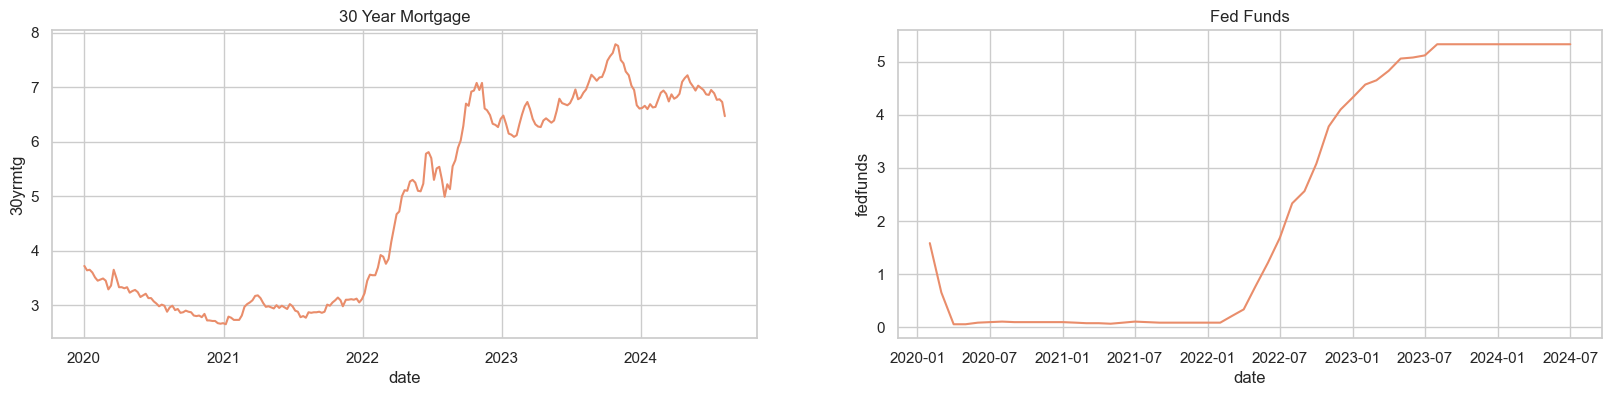

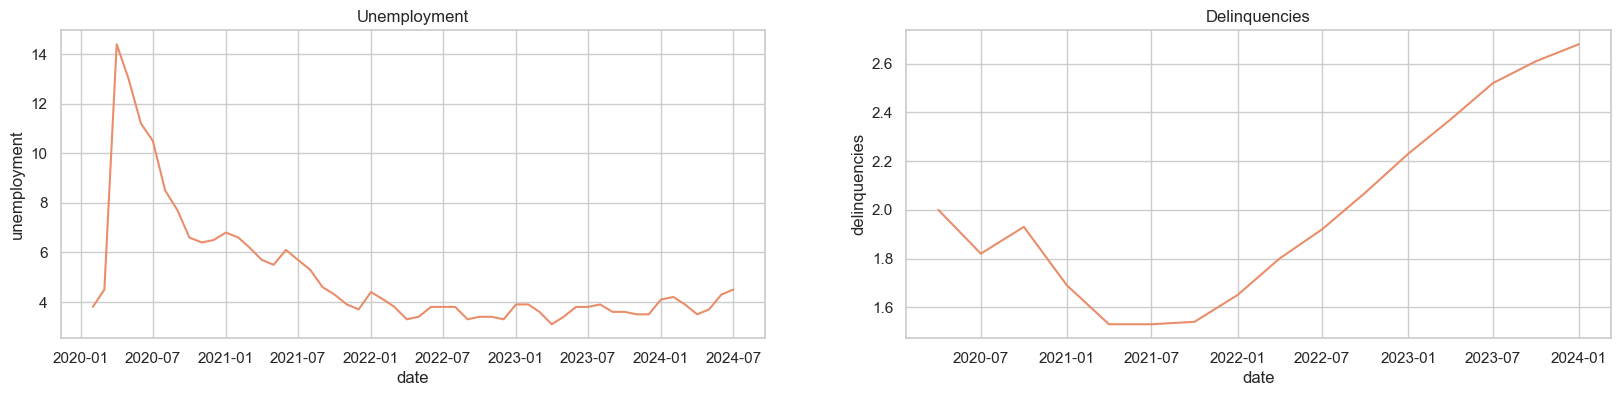

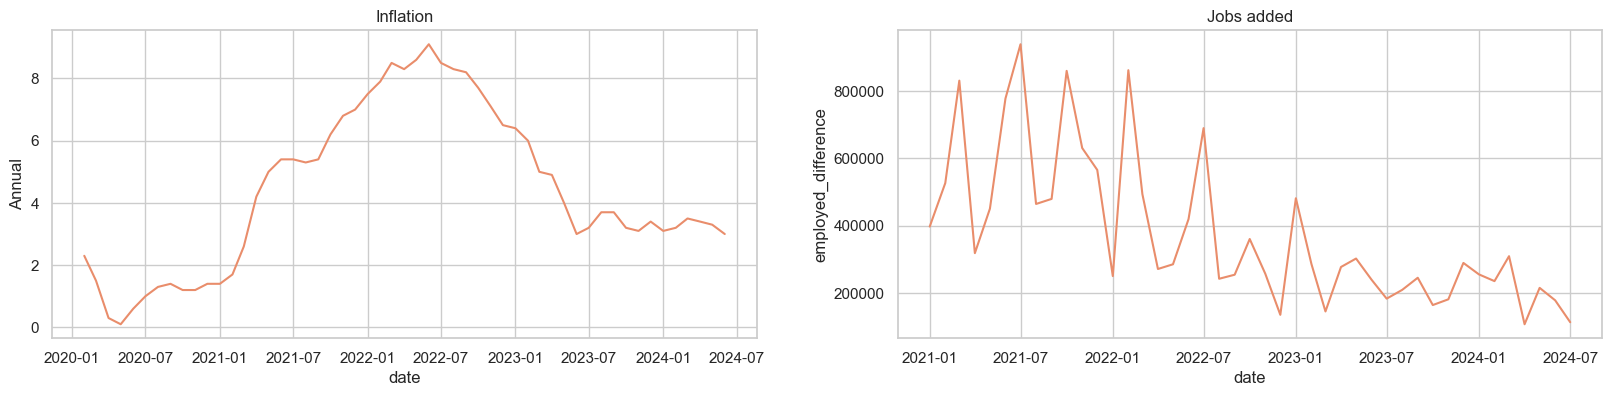

In [21]:
fig, axs = plt.subplots(ncols=2,figsize=(20,4))
dt = '2020-01-01'

ax = sns.set_theme(style="whitegrid",palette="flare")
ax = sns.lineplot(thirtyr[thirtyr['date']>dt], x = 'date',y = '30yrmtg',ax=axs[0])
ax.set_title('30 Year Mortgage')

bx = sns.set_theme(style="whitegrid",palette="flare")
bx = sns.lineplot(fedfunds[fedfunds['date']>dt], x = 'date',y = 'fedfunds',ax=axs[1])
bx.set_title('Fed Funds')

fig, axs = plt.subplots(ncols=2,figsize=(20,4))

ax = sns.set_theme(style="whitegrid",palette="flare")
ax = sns.lineplot(unemployment[unemployment['date']>dt], x = 'date',y = 'unemployment',ax=axs[0])
ax.set_title('Unemployment')

bx = sns.set_theme(style="whitegrid",palette="flare")
bx = sns.lineplot(delq_loans[delq_loans['date']>dt], x = 'date',y = 'delinquencies',ax=axs[1])
bx.set_title('Delinquencies')

fig, axs = plt.subplots(ncols=2,figsize=(20,4))
ax = sns.set_theme(style="whitegrid",palette="flare")
ax = sns.lineplot(inf[inf['date']>dt], x = 'date',y = 'Annual',ax=axs[0])
ax.set_title('Inflation')


bx = sns.set_theme(style="whitegrid",palette="flare")
bx = sns.lineplot(employed[employed['date']>='2021-01-01'], x = 'date',y = 'employed_difference',ax=axs[1])
bx.set_title('Jobs added')
plt.show()

## Price & Inflation

[*********************100%%**********************]  1 of 1 completed


inflation


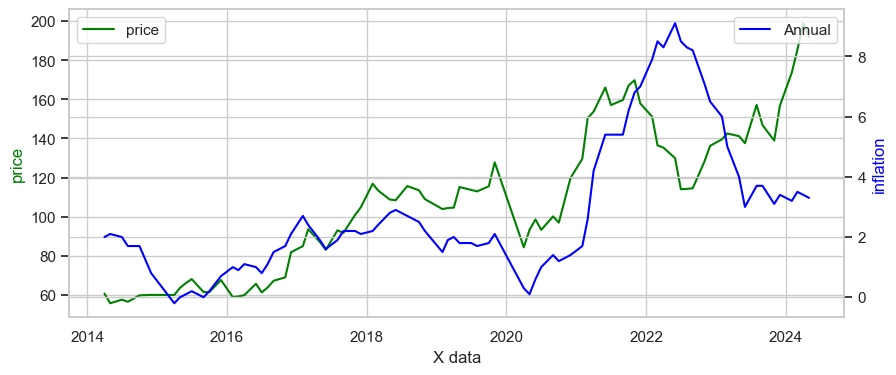

In [74]:
s = ['jpm']

fred = inf
df = yf.download(s[0], start="1980-01-01", end="2100-01-01").reset_index()
df = df[df["Date"].dt.day == 1]

history = fred.merge(df,how='inner',left_on='date',right_on='Date')[['date','Annual','Close']]

print('inflation')
fig, ax1 = plt.subplots(figsize=(10, 4))  # You can modify the width (10) and height (6) as needed

ax2 = ax1.twinx()
ax1.plot(history.date, history.Close, 'g-', label='price')  # Add a label for the green line
ax2.plot(history.date, history.Annual, 'b-', label='Annual')  # Add a label for the blue line

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

ax1.set_xlabel('X data')
ax1.set_ylabel('price', color='g')
ax2.set_ylabel('inflation', color='b')

plt.show()  # Display the plot


## Price & FedFunds

fedfunds


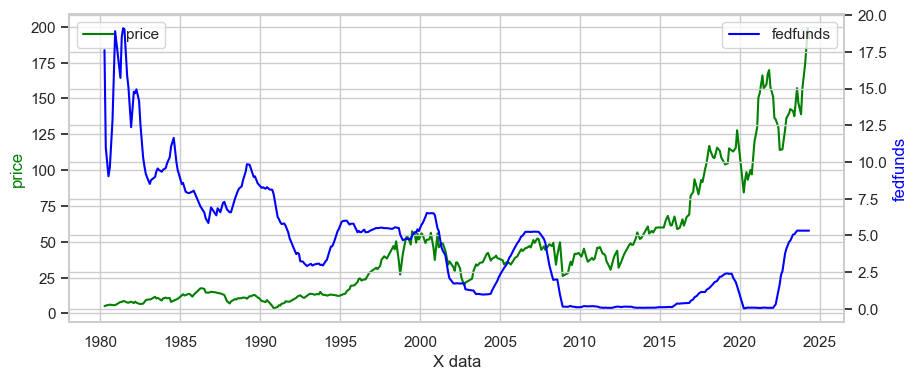

In [75]:
fred = fedfunds
print('fedfunds')
history = fred.merge(df,how='inner',left_on='date',right_on='Date')[['date','fedfunds','Close']]
fig, ax1 = plt.subplots(figsize=(10, 4))  # You can modify the width (10) and height (6) as needed

ax2 = ax1.twinx()
ax1.plot(history.date, history.Close, 'g-', label='price')  # Add a label for the green line
ax2.plot(history.date, history.fedfunds, 'b-', label='fedfunds')  # Add a label for the blue line

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

ax1.set_xlabel('X data')
ax1.set_ylabel('price', color='g')
ax2.set_ylabel('fedfunds', color='b')

plt.show()  # Display the plot

## Price & Mortgages

thirtyr


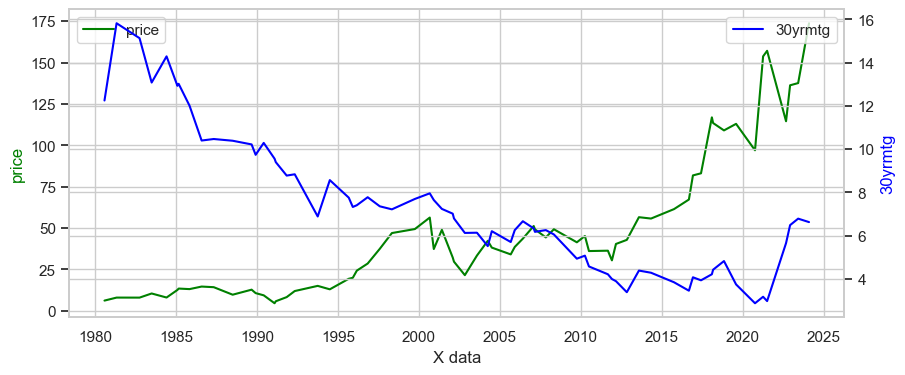

In [76]:
fred = thirtyr
print('thirtyr')
history = fred.merge(df,how='inner',left_on='date',right_on='Date')[['date','30yrmtg','Close']]
fig, ax1 = plt.subplots(figsize=(10, 4))  # You can modify the width (10) and height (6) as needed

ax2 = ax1.twinx()
ax1.plot(history.date, history.Close, 'g-', label='price')  # Add a label for the green line
ax2.plot(history.date, history['30yrmtg'], 'b-', label='30yrmtg')  # Add a label for the blue line

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

ax1.set_xlabel('X data')
ax1.set_ylabel('price', color='g')
ax2.set_ylabel('30yrmtg', color='b')

plt.show()  # Display the plot

## Price & Delinquencies

delq_loans


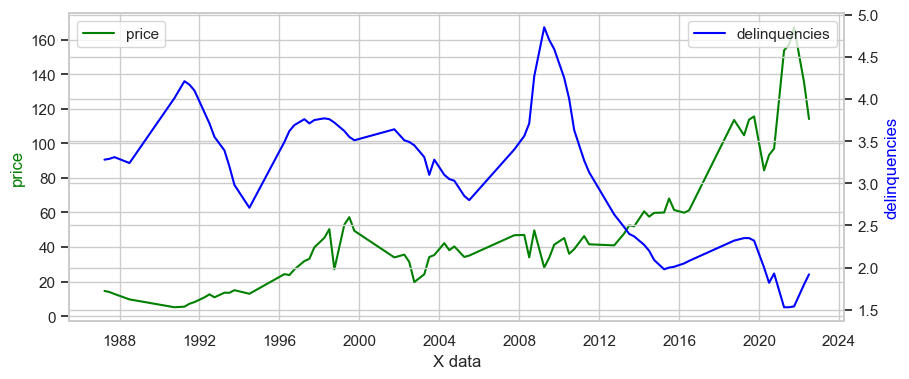

In [77]:
fred = delq_loans
print('delq_loans')
history = fred.merge(df,how='inner',left_on='date',right_on='Date')[['date','delinquencies','Close']]
fig, ax1 = plt.subplots(figsize=(10, 4))  # You can modify the width (10) and height (6) as needed

ax2 = ax1.twinx()
ax1.plot(history.date, history.Close, 'g-', label='price')  # Add a label for the green line
ax2.plot(history.date, history['delinquencies'], 'b-', label='delinquencies')  # Add a label for the blue line

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

ax1.set_xlabel('X data')
ax1.set_ylabel('price', color='g')
ax2.set_ylabel('delinquencies', color='b')

plt.show()  # Display the plot

## Price & Unemployment

unemployment


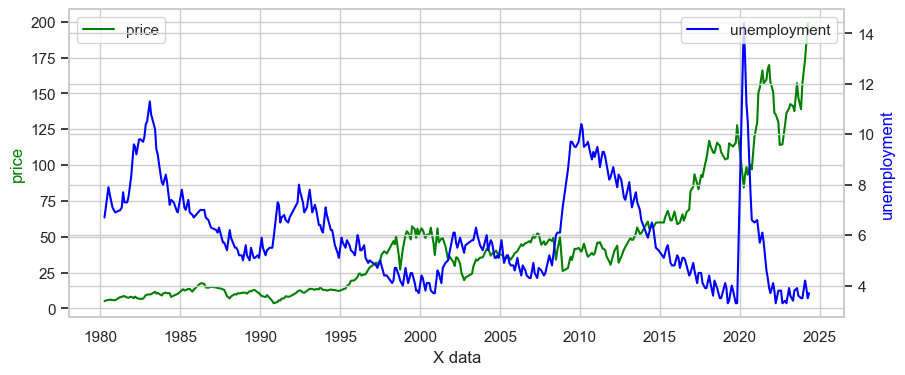

In [78]:
fred = unemployment
print('unemployment')
history = fred.merge(df,how='inner',left_on='date',right_on='Date')[['date','unemployment','Close']]
fig, ax1 = plt.subplots(figsize=(10, 4))  # You can modify the width (10) and height (6) as needed

ax2 = ax1.twinx()
ax1.plot(history.date, history.Close, 'g-', label='price')  # Add a label for the green line
ax2.plot(history.date, history['unemployment'], 'b-', label='unemployment')  # Add a label for the blue line

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

ax1.set_xlabel('X data')
ax1.set_ylabel('price', color='g')
ax2.set_ylabel('unemployment', color='b')

plt.show()  # Display the plot

In [54]:
sns.heatmap(df.corr(),annot=True)

NameError: name 'df' is not defined

<Axes: xlabel='fedfunds', ylabel='price'>

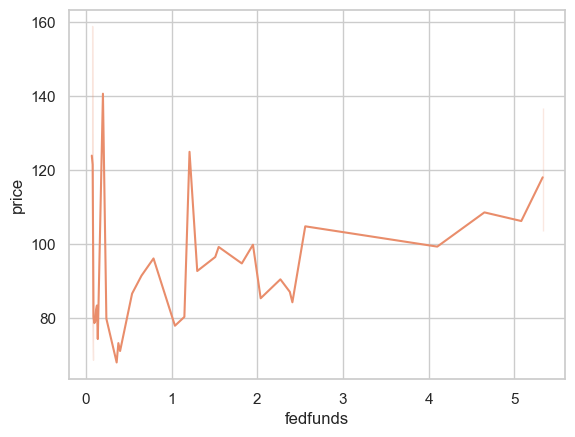

In [ ]:
sns.lineplot(df,x='fedfunds',y='price')

In [ ]:
df.sort_values('date',ascending=False).head()

,date,price,30yrmtg,fedfunds,unemployment,inflation,Annual,Revenue,Gross Margin,Net Income
40,2024-03-01,136.770,6.880,5.330,3.900,0.400,3.500,6719.000,100.000,1280.000
39,2023-12-01,113.930,7.030,5.330,3.500,0.200,3.400,6649.000,100.000,706.000
38,2023-09-01,103.500,7.120,5.330,3.600,0.400,3.700,7082.000,100.000,1790.000
37,2023-06-01,106.240,6.790,5.080,3.800,0.200,3.000,6522.000,100.000,1431.000
36,2023-03-01,108.580,6.650,4.650,3.600,0.100,5.000,6108.000,100.000,960.000


In [ ]:
df.dtypes

date            datetime64[ns]
price                  float64
30yrmtg                float64
fedfunds               float64
unemployment           float64
inflation              float64
Annual                 float64
Revenue                float64
Gross Margin           float64
Net Income             float64
dtype: object

In [ ]:
#df.to_csv('output.csv',index=False)

In [ ]:
df.columns

Index(['date', 'price', '30yrmtg', 'fedfunds', 'unemployment', 'inflation',
       'Annual'],
      dtype='object')

# Model Prep

In [ ]:
X = df[['30yrmtg', 'fedfunds','unemployment','inflation']]
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train) 
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
inf['year'] = pd.DatetimeIndex(inf['date']).year
inf['month'] = pd.DatetimeIndex(inf['date']).month
inf= inf.groupby(['year','month']).first().reset_index(drop=False)
inf['date'] = pd.to_datetime(pd.DataFrame({'day': 1,'month': inf['date'].dt.month,'year': inf['date'].dt.year},index=inf.index))
inf = inf.drop(['year','month'],axis=1)

thirtyr['year'] = pd.DatetimeIndex(thirtyr['date']).year
thirtyr['month'] = pd.DatetimeIndex(thirtyr['date']).month
thirtyr= thirtyr.groupby(['year','month']).first().reset_index(drop=False)
thirtyr['date'] = pd.to_datetime(pd.DataFrame({'day': 1,'month': thirtyr['date'].dt.month,'year': thirtyr['date'].dt.year},index=thirtyr.index))
thirtyr = thirtyr.drop(['year','month'],axis=1)

fedfunds['year'] = pd.DatetimeIndex(fedfunds['date']).year
fedfunds['month'] = pd.DatetimeIndex(fedfunds['date']).month
fedfunds= fedfunds.groupby(['year','month']).first().reset_index(drop=False)
fedfunds['date'] = pd.to_datetime(pd.DataFrame({'day': 1,'month': fedfunds['date'].dt.month,'year': fedfunds['date'].dt.year},index=fedfunds.index))
fedfunds = fedfunds.drop(['year','month'],axis=1)

unemployment['year'] = pd.DatetimeIndex(unemployment['date']).year
unemployment['month'] = pd.DatetimeIndex(unemployment['date']).month
unemployment= unemployment.groupby(['year','month']).first().reset_index(drop=False)
unemployment['date'] = pd.to_datetime(pd.DataFrame({'day': 1,'month': unemployment['date'].dt.month,'year': unemployment['date'].dt.year},index=unemployment.index))
unemployment = unemployment.drop(['year','month'],axis=1)

delq_loans['year'] = pd.DatetimeIndex(delq_loans['date']).year
delq_loans['month'] = pd.DatetimeIndex(delq_loans['date']).month
delq_loans= delq_loans.groupby(['year','month']).first().reset_index(drop=False)
delq_loans['date'] = pd.to_datetime(pd.DataFrame({'day': 1,'month': delq_loans['date'].dt.month,'year': delq_loans['date'].dt.year},index=delq_loans.index))
delq_loans = delq_loans.drop(['year','month'],axis=1)

In [ ]:
stock['date'] = pd.to_datetime(pd.DataFrame({'day': 1,'month': stock['date'].dt.month,'year': stock['date'].dt.year},index=stock.index))


# Model

### Linear Regression

In [ ]:
reg = linear_model.LinearRegression()

In [ ]:
reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = reg.predict(X_test)

In [ ]:
print(mean_squared_error(y_test, y_pred))
print(math.sqrt(mean_squared_error(y_test, y_pred)))
print(r2_score(y_test, y_pred)*100)

326.44922412876065
18.067905914321134
51.51146524831668


In [ ]:

#income['date'] = pd.to_datetime(pd.DataFrame({'day': 1,'month': income.index.dt.month,'year': income.index.dt.year},index=income.index))
#income = income.drop(['year','month'],axis=1)

### Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso

reg = Lasso(alpha=1)
reg.fit(X_train, y_train)

Lasso(alpha=1)

In [ ]:
print('R squared training set', round(reg.score(X_train, y_train)*100, 2))
print('R squared test set', round(reg.score(X_test, y_test)*100, 2))

R squared training set 58.99
R squared test set 56.26


### Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

reg = Ridge(alpha=1)
reg.fit(X_train, y_train)

Ridge(alpha=1)

In [ ]:
print('R squared training set', round(reg.score(X_train, y_train)*100, 2))
print('R squared test set', round(reg.score(X_test, y_test)*100, 2))

R squared training set 59.81
R squared test set 52.39


In [ ]:
income.columns

Index(['date', 'Revenue', 'Gross Margin', 'Net Income'], dtype='object', name='Quarter Ended')